# Làm sạch, Chuẩn hóa & Đồng bộ Dữ liệu Chất lượng Không khí

**Mục tiêu**: Làm sạch dữ liệu chất lượng không khí từ Open-Meteo, phát hiện bất thường, chuẩn hóa và đồng bộ thời gian.

**Nguồn dữ liệu**: `processed/open-meteo-daily-AQ.csv`

**Kết quả**: 
- Dữ liệu đã làm sạch: `processed/airquality_cleaned.csv`
- Báo cáo QA: `reports/qa_airquality_summary.csv`

## 1. Import Libraries và Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load dữ liệu chất lượng không khí
df_aq = pd.read_csv('../processed/open-meteo-daily-AQ.csv')

print("="*70)
print("DỮ LIỆU CHẤT LƯỢNG KHÔNG KHÍ GÓC")
print("="*70)
print(f"Số dòng: {len(df_aq)}")
print(f"Số cột: {len(df_aq.columns)}")
print(f"\nCác cột: {list(df_aq.columns)}")
print(f"\nKiểu dữ liệu:")
print(df_aq.dtypes)
print(f"\n5 dòng đầu tiên:")
df_aq.head()

DỮ LIỆU CHẤT LƯỢNG KHÔNG KHÍ GÓC
Số dòng: 366
Số cột: 7

Các cột: ['time', 'pm10 (μg/m³)', 'pm2_5 (μg/m³)', 'uv_index ()', 'ozone (μg/m³)', 'carbon_monoxide (μg/m³)', 'carbon_dioxide (ppm)']

Kiểu dữ liệu:
time                        object
pm10 (μg/m³)               float64
pm2_5 (μg/m³)              float64
uv_index ()                float64
ozone (μg/m³)              float64
carbon_monoxide (μg/m³)    float64
carbon_dioxide (ppm)       float64
dtype: object

5 dòng đầu tiên:


,time,pm10 (μg/m³),pm2_5 (μg/m³),uv_index (),ozone (μg/m³),carbon_monoxide (μg/m³),carbon_dioxide (ppm)
0,2024-01-01,59.04,39.50,7.65,58.92,692.62,NaN
1,2024-01-02,58.75,39.01,6.15,66.00,585.96,NaN
2,2024-01-03,44.80,29.48,7.30,60.96,533.12,NaN
3,2024-01-04,42.05,27.40,8.35,78.38,490.00,NaN
4,2024-01-05,43.02,28.22,7.50,65.92,563.21,NaN


## 2. Chuẩn hóa Tên Cột

In [3]:
# Đổi tên cột để đơn giản hóa
df_aq.columns = df_aq.columns.str.strip()

column_mapping = {
    'time': 'time',
    'pm10 (μg/m³)': 'pm10_ugm3',
    'pm2_5 (μg/m³)': 'pm2_5_ugm3',
    'uv_index ()': 'uv_index',
    'ozone (μg/m³)': 'ozone_ugm3',
    'carbon_monoxide (μg/m³)': 'co_ugm3',
    'carbon_dioxide (ppm)': 'co2_ppm'
}

df_aq.rename(columns=column_mapping, inplace=True)

print("✓ Đã chuẩn hóa tên cột")
print(f"Các cột mới: {list(df_aq.columns)}")

✓ Đã chuẩn hóa tên cột
Các cột mới: ['time', 'pm10_ugm3', 'pm2_5_ugm3', 'uv_index', 'ozone_ugm3', 'co_ugm3', 'co2_ppm']


## 3. Chuyển đổi và Chuẩn hóa Thời gian

In [4]:
# Chuyển cột time sang datetime
df_aq['time'] = pd.to_datetime(df_aq['time'])

# Đặt time làm index
df_aq.set_index('time', inplace=True)

# Sắp xếp theo thời gian
df_aq.sort_index(inplace=True)

print("✓ Đã chuyển đổi cột time sang datetime và đặt làm index")
print(f"Khoảng thời gian: {df_aq.index.min()} đến {df_aq.index.max()}")
print(f"Số ngày: {len(df_aq)}")

df_aq.head()

✓ Đã chuyển đổi cột time sang datetime và đặt làm index
Khoảng thời gian: 2024-01-01 00:00:00 đến 2024-12-31 00:00:00
Số ngày: 366


,pm10_ugm3,pm2_5_ugm3,uv_index,ozone_ugm3,co_ugm3,co2_ppm
time,,,,,,
2024-01-01,59.04,39.50,7.65,58.92,692.62,NaN
2024-01-02,58.75,39.01,6.15,66.00,585.96,NaN
2024-01-03,44.80,29.48,7.30,60.96,533.12,NaN
2024-01-04,42.05,27.40,8.35,78.38,490.00,NaN
2024-01-05,43.02,28.22,7.50,65.92,563.21,NaN


## 4. Khởi tạo Báo cáo QA

In [5]:
# Tạo DataFrame để lưu báo cáo QA
qa_report = []

def add_qa_record(rule_name, issue_count, total_count, description, action_taken):
    """Thêm một bản ghi vào báo cáo QA"""
    percentage = (issue_count / total_count * 100) if total_count > 0 else 0
    qa_report.append({
        'Rule': rule_name,
        'Issues_Found': issue_count,
        'Total_Records': total_count,
        'Percentage': f"{percentage:.2f}%",
        'Description': description,
        'Action_Taken': action_taken
    })

print("✓ Đã khởi tạo hệ thống báo cáo QA")

✓ Đã khởi tạo hệ thống báo cáo QA


## 5. Kiểm tra Dữ liệu Thiếu (Missing Data)

In [6]:
print("="*70)
print("KIỂM TRA DỮ LIỆU THIẾU")
print("="*70)

missing_data = df_aq.isnull().sum()
missing_percentage = (missing_data / len(df_aq) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_percentage
})

print(missing_summary)

# Thêm vào báo cáo QA
for col in df_aq.columns:
    missing_count = missing_data[col]
    if missing_count > 0:
        add_qa_record(
            rule_name=f"Missing_{col}",
            issue_count=missing_count,
            total_count=len(df_aq),
            description=f"Giá trị thiếu trong cột {col}",
            action_taken="Gắn cờ 'is_missing', giữ nguyên giá trị NaN để phân tích sau"
        )

# Tạo cờ cho dữ liệu thiếu
for col in df_aq.columns:
    df_aq[f'{col}_missing'] = df_aq[col].isnull().astype(int)

print("\n✓ Đã gắn cờ cho các giá trị thiếu")

KIỂM TRA DỮ LIỆU THIẾU
            Missing_Count  Percentage
pm10_ugm3               0        0.00
pm2_5_ugm3              0        0.00
uv_index                0        0.00
ozone_ugm3              0        0.00
co_ugm3                 0        0.00
co2_ppm               299       81.69

✓ Đã gắn cờ cho các giá trị thiếu


## 6. Kiểm tra Giá trị Âm Không Hợp lệ

In [7]:
print("="*70)
print("KIỂM TRA GIÁ TRỊ ÂM KHÔNG HỢP LỆ")
print("="*70)

# Tất cả các cột nồng độ không được có giá trị âm
non_negative_cols = ['pm10_ugm3', 'pm2_5_ugm3', 'uv_index', 'ozone_ugm3', 'co_ugm3', 'co2_ppm']

for col in non_negative_cols:
    if col in df_aq.columns:
        negative_count = (df_aq[col] < 0).sum()
        print(f"{col}: {negative_count} giá trị âm")
        
        if negative_count > 0:
            add_qa_record(
                rule_name=f"Negative_{col}",
                issue_count=negative_count,
                total_count=len(df_aq),
                description=f"Giá trị âm không hợp lệ trong {col}",
                action_taken="Gắn cờ 'invalid_negative'"
            )
            
            # Gắn cờ
            df_aq[f'{col}_invalid_negative'] = (df_aq[col] < 0).astype(int)
            
            # Hiển thị các giá trị âm
            print(f"  Các giá trị âm trong {col}:")
            print(df_aq[df_aq[col] < 0][[col]])
        else:
            df_aq[f'{col}_invalid_negative'] = 0

print("\n✓ Đã kiểm tra giá trị âm")

KIỂM TRA GIÁ TRỊ ÂM KHÔNG HỢP LỆ
pm10_ugm3: 0 giá trị âm
pm2_5_ugm3: 0 giá trị âm
uv_index: 0 giá trị âm
ozone_ugm3: 0 giá trị âm
co_ugm3: 0 giá trị âm
co2_ppm: 0 giá trị âm

✓ Đã kiểm tra giá trị âm


## 7. Kiểm tra UV Index Ngoài Ngưỡng

In [8]:
print("="*70)
print("KIỂM TRA UV INDEX NGOÀI NGƯỠNG")
print("="*70)

# UV Index hợp lệ: 0-15 (WHO scale)
UV_MIN = 0
UV_MAX = 15

if 'uv_index' in df_aq.columns:
    invalid_uv = ((df_aq['uv_index'] < UV_MIN) | (df_aq['uv_index'] > UV_MAX))
    invalid_count = invalid_uv.sum()
    
    print(f"Ngưỡng hợp lệ: {UV_MIN} - {UV_MAX} (WHO scale)")
    print(f"Số giá trị ngoài ngưỡng: {invalid_count}")
    
    if invalid_count > 0:
        add_qa_record(
            rule_name="UV_Index_OutOfRange",
            issue_count=invalid_count,
            total_count=len(df_aq),
            description=f"UV Index ngoài ngưỡng [{UV_MIN}, {UV_MAX}]",
            action_taken="Gắn cờ 'invalid_uv'"
        )
        
        # Gắn cờ
        df_aq['uv_index_invalid_range'] = invalid_uv.astype(int)
        
        # Hiển thị
        print(f"\nCác giá trị ngoài ngưỡng:")
        print(df_aq[invalid_uv][['uv_index']])
    else:
        print("✓ Tất cả giá trị UV Index đều trong ngưỡng hợp lệ")
        df_aq['uv_index_invalid_range'] = 0

KIỂM TRA UV INDEX NGOÀI NGƯỠNG
Ngưỡng hợp lệ: 0 - 15 (WHO scale)
Số giá trị ngoài ngưỡng: 0
✓ Tất cả giá trị UV Index đều trong ngưỡng hợp lệ


## 8. Kiểm tra PM2.5 vs PM10 Logic

In [9]:
print("="*70)
print("KIỂM TRA PM2.5 vs PM10 LOGIC")
print("="*70)

# PM2.5 không thể lớn hơn PM10 (về mặt lý thuyết)
# PM2.5 là hạt nhỏ hơn 2.5μm, PM10 là hạt nhỏ hơn 10μm
# → PM10 phải bao gồm PM2.5, nên PM10 >= PM2.5

if 'pm2_5_ugm3' in df_aq.columns and 'pm10_ugm3' in df_aq.columns:
    # Chỉ kiểm tra khi cả 2 giá trị đều không null
    valid_rows = df_aq[['pm2_5_ugm3', 'pm10_ugm3']].notna().all(axis=1)
    invalid_pm_logic = (df_aq.loc[valid_rows, 'pm2_5_ugm3'] > df_aq.loc[valid_rows, 'pm10_ugm3'])
    invalid_count = invalid_pm_logic.sum()
    
    print(f"Số dòng kiểm tra (cả 2 giá trị không null): {valid_rows.sum()}")
    print(f"Số trường hợp PM2.5 > PM10 (không hợp lệ): {invalid_count}")
    
    if invalid_count > 0:
        add_qa_record(
            rule_name="PM_Logic_Violation",
            issue_count=invalid_count,
            total_count=valid_rows.sum(),
            description="PM2.5 lớn hơn PM10 (vi phạm logic vật lý)",
            action_taken="Gắn cờ 'invalid_pm_logic'"
        )
        
        # Gắn cờ (khởi tạo toàn bộ cột = 0 trước)
        df_aq['pm_invalid_logic'] = 0
        df_aq.loc[valid_rows, 'pm_invalid_logic'] = invalid_pm_logic.astype(int)
        
        # Hiển thị các trường hợp vi phạm
        print(f"\nCác trường hợp vi phạm:")
        violation_mask = df_aq['pm_invalid_logic'] == 1
        print(df_aq[violation_mask][['pm2_5_ugm3', 'pm10_ugm3']])
    else:
        print("✓ Tất cả các giá trị đều tuân thủ logic PM2.5 <= PM10")
        df_aq['pm_invalid_logic'] = 0

KIỂM TRA PM2.5 vs PM10 LOGIC
Số dòng kiểm tra (cả 2 giá trị không null): 366
Số trường hợp PM2.5 > PM10 (không hợp lệ): 0
✓ Tất cả các giá trị đều tuân thủ logic PM2.5 <= PM10


## 9. Kiểm tra PM10 Ngoài Ngưỡng

In [10]:
print("="*70)
print("KIỂM TRA PM10 NGOÀI NGƯỠNG")
print("="*70)

# Ngưỡng hợp lệ cho PM10 ở khu vực đô thị
# Theo WHO và các nghiên cứu, giá trị cực đại ghi nhận hiếm khi vượt 500 μg/m³
PM10_MIN = 0
PM10_MAX = 500  # μg/m³

if 'pm10_ugm3' in df_aq.columns:
    invalid_pm10 = ((df_aq['pm10_ugm3'] < PM10_MIN) | (df_aq['pm10_ugm3'] > PM10_MAX))
    invalid_count = invalid_pm10.sum()
    
    print(f"Ngưỡng hợp lệ: {PM10_MIN} - {PM10_MAX} μg/m³")
    print(f"Số giá trị ngoài ngưỡng: {invalid_count}")
    
    if invalid_count > 0:
        add_qa_record(
            rule_name="PM10_OutOfRange",
            issue_count=invalid_count,
            total_count=len(df_aq),
            description=f"PM10 ngoài ngưỡng [{PM10_MIN}, {PM10_MAX}] μg/m³",
            action_taken="Gắn cờ 'invalid_pm10_range'"
        )
        
        df_aq['pm10_ugm3_invalid_range'] = invalid_pm10.astype(int)
        
        print(f"\nCác giá trị ngoài ngưỡng:")
        print(df_aq[invalid_pm10][['pm10_ugm3']])
    else:
        print("✓ Tất cả giá trị PM10 đều trong ngưỡng hợp lệ")
        df_aq['pm10_ugm3_invalid_range'] = 0

KIỂM TRA PM10 NGOÀI NGƯỠNG
Ngưỡng hợp lệ: 0 - 500 μg/m³
Số giá trị ngoài ngưỡng: 0
✓ Tất cả giá trị PM10 đều trong ngưỡng hợp lệ


## 10. Kiểm tra PM2.5 Ngoài Ngưỡng

In [11]:
print("="*70)
print("KIỂM TRA PM2.5 NGOÀI NGƯỠNG")
print("="*70)

# Ngưỡng hợp lệ cho PM2.5
PM25_MIN = 0
PM25_MAX = 300  # μg/m³

if 'pm2_5_ugm3' in df_aq.columns:
    invalid_pm25 = ((df_aq['pm2_5_ugm3'] < PM25_MIN) | (df_aq['pm2_5_ugm3'] > PM25_MAX))
    invalid_count = invalid_pm25.sum()
    
    print(f"Ngưỡng hợp lệ: {PM25_MIN} - {PM25_MAX} μg/m³")
    print(f"Số giá trị ngoài ngưỡng: {invalid_count}")
    
    if invalid_count > 0:
        add_qa_record(
            rule_name="PM2.5_OutOfRange",
            issue_count=invalid_count,
            total_count=len(df_aq),
            description=f"PM2.5 ngoài ngưỡng [{PM25_MIN}, {PM25_MAX}] μg/m³",
            action_taken="Gắn cờ 'invalid_pm25_range'"
        )
        
        df_aq['pm2_5_ugm3_invalid_range'] = invalid_pm25.astype(int)
        
        print(f"\nCác giá trị ngoài ngưỡng:")
        print(df_aq[invalid_pm25][['pm2_5_ugm3']])
    else:
        print("✓ Tất cả giá trị PM2.5 đều trong ngưỡng hợp lệ")
        df_aq['pm2_5_ugm3_invalid_range'] = 0

KIỂM TRA PM2.5 NGOÀI NGƯỠNG
Ngưỡng hợp lệ: 0 - 300 μg/m³
Số giá trị ngoài ngưỡng: 0
✓ Tất cả giá trị PM2.5 đều trong ngưỡng hợp lệ


## 11. Kiểm tra Timestamp Trùng lặp

In [12]:
print("="*70)
print("KIỂM TRA TIMESTAMP TRÙNG LẶP")
print("="*70)

duplicate_timestamps = df_aq.index.duplicated().sum()
print(f"Số timestamp trùng lặp: {duplicate_timestamps}")

if duplicate_timestamps > 0:
    add_qa_record(
        rule_name="Duplicate_Timestamps",
        issue_count=duplicate_timestamps,
        total_count=len(df_aq),
        description="Timestamp bị trùng lặp",
        action_taken="Giữ dòng đầu tiên, xóa các dòng trùng"
    )
    
    # Hiển thị các timestamp trùng
    print("\nCác timestamp bị trùng:")
    print(df_aq[df_aq.index.duplicated(keep=False)])
    
    # Xóa trùng lặp - giữ dòng đầu tiên
    df_aq = df_aq[~df_aq.index.duplicated(keep='first')]
    print(f"\n✓ Đã xóa {duplicate_timestamps} dòng trùng lặp")
else:
    print("✓ Không có timestamp trùng lặp")

KIỂM TRA TIMESTAMP TRÙNG LẶP
Số timestamp trùng lặp: 0
✓ Không có timestamp trùng lặp


## 12. Kiểm tra Chuỗi Thời gian Bị Đứt đoạn

In [13]:
print("="*70)
print("KIỂM TRA CHUỖI THỜI GIAN BỊ ĐỨT ĐOẠN")
print("="*70)

# Tạo chuỗi thời gian đầy đủ
date_range = pd.date_range(start=df_aq.index.min(), 
                           end=df_aq.index.max(), 
                           freq='D')

missing_dates = date_range.difference(df_aq.index)
missing_count = len(missing_dates)

print(f"Khoảng thời gian: {df_aq.index.min()} đến {df_aq.index.max()}")
print(f"Số ngày mong đợi: {len(date_range)}")
print(f"Số ngày thực tế: {len(df_aq)}")
print(f"Số ngày bị thiếu: {missing_count}")

if missing_count > 0:
    add_qa_record(
        rule_name="Missing_Dates",
        issue_count=missing_count,
        total_count=len(date_range),
        description="Ngày bị thiếu trong chuỗi thời gian",
        action_taken="Reindex với tần suất daily, giá trị thiếu để NaN"
    )
    
    print(f"\nCác ngày bị thiếu:")
    for date in missing_dates[:10]:  # Hiển thị 10 ngày đầu
        print(f"  {date.date()}")
    if missing_count > 10:
        print(f"  ... và {missing_count - 10} ngày khác")
    
    # Reindex để điền đầy chuỗi thời gian
    df_aq = df_aq.reindex(date_range)
    print(f"\n✓ Đã reindex, số dòng sau reindex: {len(df_aq)}")
else:
    print("✓ Chuỗi thời gian liên tục, không bị đứt đoạn")

KIỂM TRA CHUỖI THỜI GIAN BỊ ĐỨT ĐOẠN
Khoảng thời gian: 2024-01-01 00:00:00 đến 2024-12-31 00:00:00
Số ngày mong đợi: 366
Số ngày thực tế: 366
Số ngày bị thiếu: 0
✓ Chuỗi thời gian liên tục, không bị đứt đoạn


## 13. Thống kê Tổng quan sau Kiểm tra

In [14]:
print("="*70)
print("THỐNG KÊ TỔNG QUAN SAU KIỂM TRA")
print("="*70)

print(f"\nSố dòng sau làm sạch: {len(df_aq)}")
print(f"\nThống kê mô tả:")
numeric_cols = ['pm10_ugm3', 'pm2_5_ugm3', 'uv_index', 'ozone_ugm3', 'co_ugm3', 'co2_ppm']
print(df_aq[numeric_cols].describe())

THỐNG KÊ TỔNG QUAN SAU KIỂM TRA

Số dòng sau làm sạch: 366

Thống kê mô tả:
        pm10_ugm3  pm2_5_ugm3    uv_index  ozone_ugm3      co_ugm3     co2_ppm
count  366.000000  366.000000  366.000000  366.000000   366.000000   67.000000
mean    32.318689   22.669481    8.832787   54.012240   501.328661  464.893731
std     11.460982    8.959361    2.189215   15.014331   281.290978    8.895652
min     10.380000    9.110000    2.250000   18.080000   186.120000  449.620000
25%     22.782500   15.282500    7.512500   42.520000   307.670000  457.460000
50%     30.420000   21.475000    8.975000   51.940000   425.855000  463.830000
75%     40.550000   28.742500   10.250000   65.887500   572.112500  469.795000
max     62.540000   54.400000   13.900000   92.120000  1917.540000  492.920000


## 14. Tạo Cờ Tổng hợp (Composite Flag)

In [15]:
print("="*70)
print("TẠO CỜ TỔNG HỢP")
print("="*70)

# Tạo cờ tổng hợp cho dữ liệu có vấn đề
flag_columns = [col for col in df_aq.columns if 'missing' in col or 'invalid' in col]

print(f"Các cột cờ: {flag_columns}")

# Tạo cờ tổng hợp: 1 nếu có bất kỳ vấn đề nào
df_aq['has_quality_issues'] = df_aq[flag_columns].sum(axis=1) > 0
df_aq['has_quality_issues'] = df_aq['has_quality_issues'].astype(int)

issues_count = df_aq['has_quality_issues'].sum()
issues_percentage = (issues_count / len(df_aq) * 100)

print(f"\nSố dòng có vấn đề chất lượng: {issues_count}/{len(df_aq)} ({issues_percentage:.2f}%)")
print(f"Số dòng không có vấn đề: {len(df_aq) - issues_count}/{len(df_aq)} ({100-issues_percentage:.2f}%)")

TẠO CỜ TỔNG HỢP
Các cột cờ: ['pm10_ugm3_missing', 'pm2_5_ugm3_missing', 'uv_index_missing', 'ozone_ugm3_missing', 'co_ugm3_missing', 'co2_ppm_missing', 'pm10_ugm3_invalid_negative', 'pm2_5_ugm3_invalid_negative', 'uv_index_invalid_negative', 'ozone_ugm3_invalid_negative', 'co_ugm3_invalid_negative', 'co2_ppm_invalid_negative', 'uv_index_invalid_range', 'pm_invalid_logic', 'pm10_ugm3_invalid_range', 'pm2_5_ugm3_invalid_range']

Số dòng có vấn đề chất lượng: 299/366 (81.69%)
Số dòng không có vấn đề: 67/366 (18.31%)


## 15. Lưu Báo cáo QA

In [16]:
import os

# Tạo thư mục reports nếu chưa có
os.makedirs('../reports', exist_ok=True)

# Chuyển báo cáo QA thành DataFrame
df_qa = pd.DataFrame(qa_report)

# Lưu báo cáo
qa_output_path = '../reports/qa_airquality_summary.csv'
df_qa.to_csv(qa_output_path, index=False)

print("="*70)
print("BÁO CÁO QA")
print("="*70)
print(df_qa.to_string(index=False))
print(f"\n✓ Đã lưu báo cáo QA tại: {qa_output_path}")

BÁO CÁO QA
           Rule  Issues_Found  Total_Records Percentage                     Description                                                 Action_Taken
Missing_co2_ppm           299            366     81.69% Giá trị thiếu trong cột co2_ppm Gắn cờ 'is_missing', giữ nguyên giá trị NaN để phân tích sau

✓ Đã lưu báo cáo QA tại: ../reports/qa_airquality_summary.csv


## 16. Lưu Dữ liệu Đã Làm sạch

In [17]:
# Tạo thư mục processed nếu chưa có
os.makedirs('../processed', exist_ok=True)

# Reset index để time thành cột
df_aq_output = df_aq.reset_index()
df_aq_output.rename(columns={'index': 'time'}, inplace=True)

# Lưu dữ liệu đã làm sạch
output_path = '../processed/airquality_cleaned.csv'
df_aq_output.to_csv(output_path, index=False)

print("="*70)
print("LƯU DỮ LIỆU ĐÃ LÀM SẠCH")
print("="*70)
print(f"✓ Đã lưu dữ liệu tại: {output_path}")
print(f"  Số dòng: {len(df_aq_output)}")
print(f"  Số cột: {len(df_aq_output.columns)}")
print(f"\n5 dòng đầu tiên:")
df_aq_output.head()

LƯU DỮ LIỆU ĐÃ LÀM SẠCH
✓ Đã lưu dữ liệu tại: ../processed/airquality_cleaned.csv
  Số dòng: 366
  Số cột: 24

5 dòng đầu tiên:


,time,pm10_ugm3,pm2_5_ugm3,uv_index,ozone_ugm3,co_ugm3,co2_ppm,pm10_ugm3_missing,pm2_5_ugm3_missing,uv_index_missing,ozone_ugm3_missing,co_ugm3_missing,co2_ppm_missing,pm10_ugm3_invalid_negative,pm2_5_ugm3_invalid_negative,uv_index_invalid_negative,ozone_ugm3_invalid_negative,co_ugm3_invalid_negative,co2_ppm_invalid_negative,uv_index_invalid_range,pm_invalid_logic,pm10_ugm3_invalid_range,pm2_5_ugm3_invalid_range,has_quality_issues
0,2024-01-01,59.04,39.50,7.65,58.92,692.62,NaN,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
1,2024-01-02,58.75,39.01,6.15,66.00,585.96,NaN,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
2,2024-01-03,44.80,29.48,7.30,60.96,533.12,NaN,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
3,2024-01-04,42.05,27.40,8.35,78.38,490.00,NaN,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,2024-01-05,43.02,28.22,7.50,65.92,563.21,NaN,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1


## 17. Visualizations

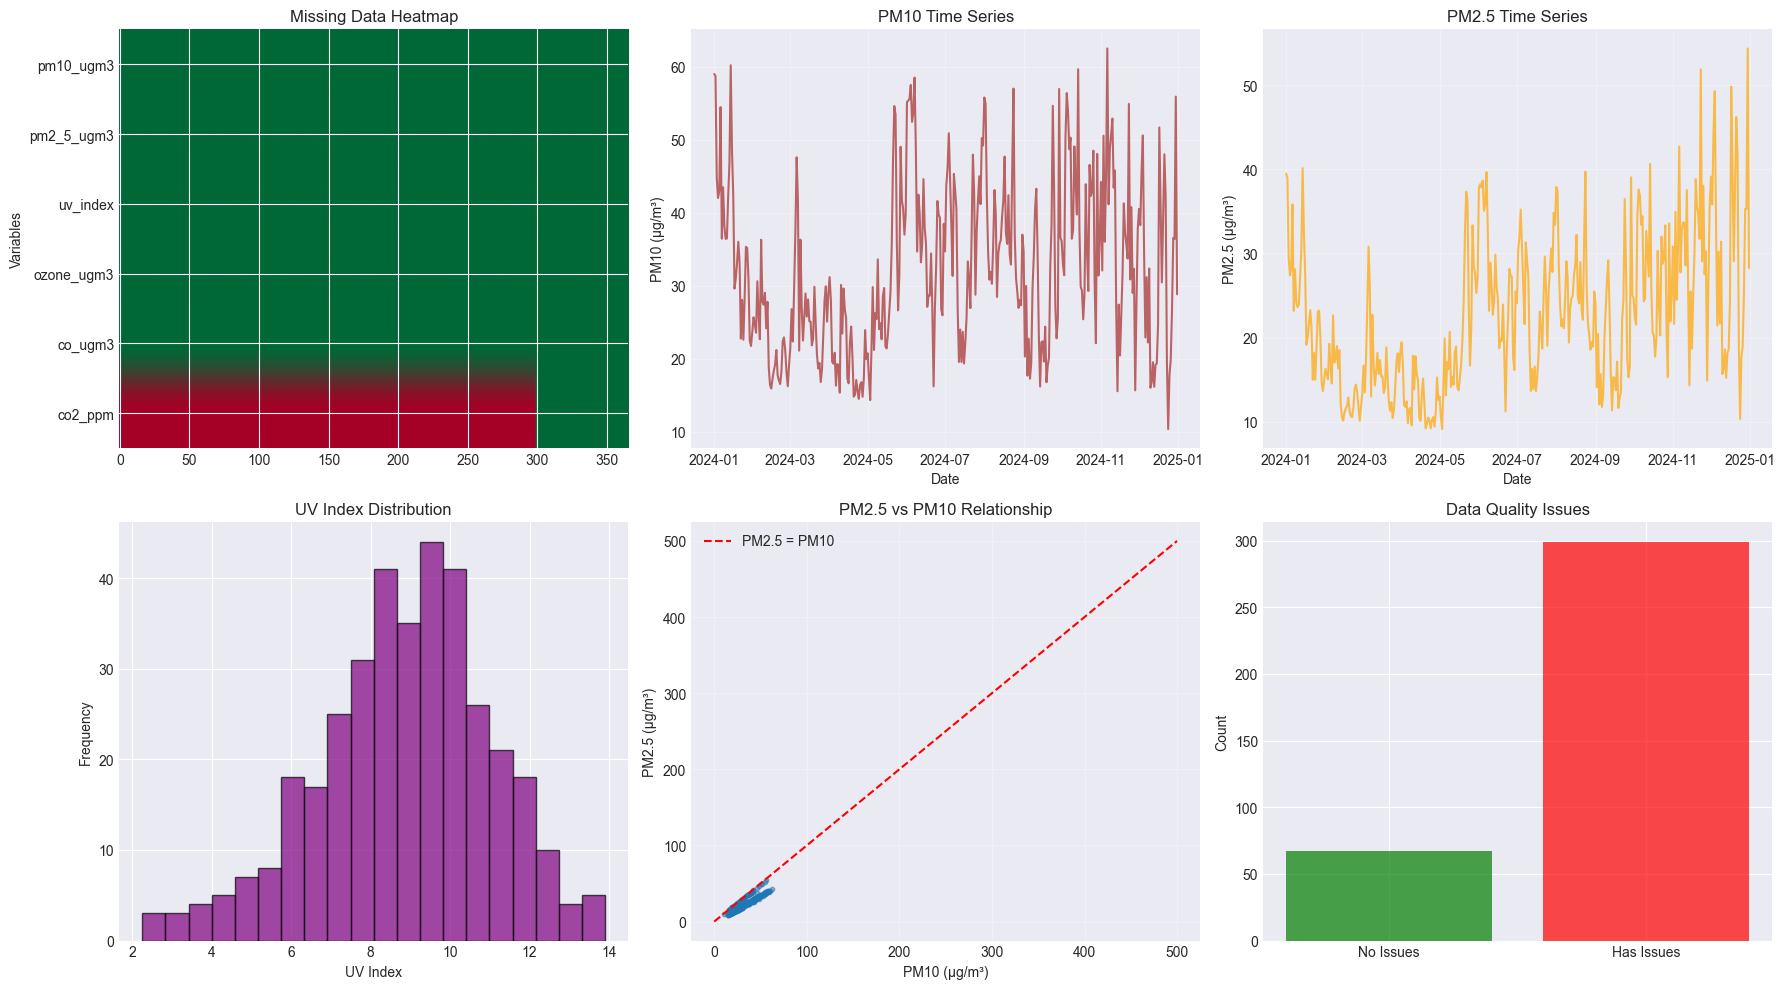

✓ Đã lưu visualization tại: ../reports/airquality_qa_visualization.pdf


In [18]:
# Visualize data quality issues
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Missing data heatmap
missing_cols = ['pm10_ugm3', 'pm2_5_ugm3', 'uv_index', 'ozone_ugm3', 'co_ugm3', 'co2_ppm']
missing_data_viz = df_aq_output[missing_cols].isnull().astype(int)
axes[0, 0].imshow(missing_data_viz.T, aspect='auto', cmap='RdYlGn_r')
axes[0, 0].set_title('Missing Data Heatmap')
axes[0, 0].set_ylabel('Variables')
axes[0, 0].set_yticks(range(len(missing_cols)))
axes[0, 0].set_yticklabels(missing_cols)

# 2. PM10 time series
axes[0, 1].plot(df_aq_output['time'], df_aq_output['pm10_ugm3'], color='brown', alpha=0.7)
axes[0, 1].set_title('PM10 Time Series')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('PM10 (μg/m³)')
axes[0, 1].grid(True, alpha=0.3)

# 3. PM2.5 time series
axes[0, 2].plot(df_aq_output['time'], df_aq_output['pm2_5_ugm3'], color='orange', alpha=0.7)
axes[0, 2].set_title('PM2.5 Time Series')
axes[0, 2].set_xlabel('Date')
axes[0, 2].set_ylabel('PM2.5 (μg/m³)')
axes[0, 2].grid(True, alpha=0.3)

# 4. UV Index distribution
axes[1, 0].hist(df_aq_output['uv_index'].dropna(), bins=20, edgecolor='black', color='purple', alpha=0.7)
axes[1, 0].set_title('UV Index Distribution')
axes[1, 0].set_xlabel('UV Index')
axes[1, 0].set_ylabel('Frequency')

# 5. PM2.5 vs PM10 scatter
axes[1, 1].scatter(df_aq_output['pm10_ugm3'], df_aq_output['pm2_5_ugm3'], alpha=0.5, s=10)
axes[1, 1].plot([0, 500], [0, 500], 'r--', label='PM2.5 = PM10')
axes[1, 1].set_title('PM2.5 vs PM10 Relationship')
axes[1, 1].set_xlabel('PM10 (μg/m³)')
axes[1, 1].set_ylabel('PM2.5 (μg/m³)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Quality issues distribution
quality_summary = df_aq_output['has_quality_issues'].value_counts()
axes[1, 2].bar(['No Issues', 'Has Issues'], 
               [quality_summary.get(0, 0), quality_summary.get(1, 0)],
               color=['green', 'red'], alpha=0.7)
axes[1, 2].set_title('Data Quality Issues')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/airquality_qa_visualization.pdf', bbox_inches='tight')
plt.show()

print("✓ Đã lưu visualization tại: ../reports/airquality_qa_visualization.pdf")

## 18. Tóm tắt Cuối cùng

In [19]:
print("="*70)
print("TÓM TẮT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU CHẤT LƯỢNG KHÔNG KHÍ")
print("="*70)
print(f"\n📁 File gốc: processed/open-meteo-daily-AQ.csv")
print(f"📁 File đã làm sạch: processed/airquality_cleaned.csv")
print(f"📁 Báo cáo QA: reports/qa_airquality_summary.csv")
print(f"📁 Visualization: reports/airquality_qa_visualization.pdf")

print(f"\n📊 Thống kê:")
print(f"  - Tổng số quy tắc kiểm tra: {len(qa_report)}")
print(f"  - Số dòng ban đầu: {len(df_aq_output)}")
print(f"  - Số dòng có vấn đề: {issues_count} ({issues_percentage:.2f}%)")
print(f"  - Số dòng sạch: {len(df_aq_output) - issues_count} ({100-issues_percentage:.2f}%)")

print(f"\n✅ HOÀN TẤT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU CHẤT LƯỢNG KHÔNG KHÍ!")
print("="*70)

TÓM TẮT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU CHẤT LƯỢNG KHÔNG KHÍ

📁 File gốc: processed/open-meteo-daily-AQ.csv
📁 File đã làm sạch: processed/airquality_cleaned.csv
📁 Báo cáo QA: reports/qa_airquality_summary.csv
📁 Visualization: reports/airquality_qa_visualization.pdf

📊 Thống kê:
  - Tổng số quy tắc kiểm tra: 1
  - Số dòng ban đầu: 366
  - Số dòng có vấn đề: 299 (81.69%)
  - Số dòng sạch: 67 (18.31%)

✅ HOÀN TẤT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU CHẤT LƯỢNG KHÔNG KHÍ!
